# InferenceIndexBuilder Demo

This notebook demonstrates the usage of the InferenceIndexBuilder class for building FAISS indices and performing place recognition and localization using the OPR framework.

## 1. Environment Setup and Imports

In [1]:
# Standard library imports
import sys
from pathlib import Path
import logging

# Add source path for module imports
sys.path.append("../src")

# Set up logging for better debugging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [2]:
from tf_math import Transform as Tf
import open3d as o3d
import pypcd4 as pypcd
import numpy as np

In [3]:
import torch
torch.cuda.is_available()

True

In [4]:
# Import the InferenceIndexBuilder components
from mmpr.modules.inference_index_builder import IndexConfig, InferenceIndexBuilder

print("Successfully imported InferenceIndexBuilder module")
print("All dependencies loaded successfully")

2025-10-01 12:42:57,031 - INFO - Loading faiss with AVX2 support.
2025-10-01 12:42:57,032 - INFO - Could not load library with AVX2 support due to:
ModuleNotFoundError("No module named 'faiss.swigfaiss_avx2'")
2025-10-01 12:42:57,032 - INFO - Loading faiss.
2025-10-01 12:42:57,054 - INFO - Successfully loaded faiss.
2025-10-01 12:42:57.060 | WARNING  | opr.models.place_recognition.pointmamba:<module>:16 - The 'pointmamba' package is not installed. Please install it manually if neccessary.


Successfully imported InferenceIndexBuilder module
All dependencies loaded successfully


## 2. Configuration and Data Path Setup

Define the data paths and load configuration. The expected directory structure is:

```
dataset/
├── map1/keyframe_map/
│   ├── poses.csv          # Reference map trajectory
│   └── scans/             # Reference map point clouds
│       ├── 000000.pcd
│       ├── 000001.pcd
│       └── ...
└── map2/keyframe_map/     # Query map for testing
    ├── poses.csv
    └── scans/
```

In [5]:
# Define data paths
ROOT_DATA_DIR = Path("/home/docker_mmpr/Datasets/mmpr_dataset")
CONFIG_PATH = "../src/mmpr/configs/default.yaml"

# Define map directories
REFERENCE_MAP = "map1/keyframe_map"  # Map used to build the index
QUERY_MAP = "map2/keyframe_map"      # Map used for testing queries

# Construct full paths
reference_map_dir = ROOT_DATA_DIR / REFERENCE_MAP
query_map_dir = ROOT_DATA_DIR / QUERY_MAP

# Validate paths exist
assert reference_map_dir.exists(), f"Reference map directory not found: {reference_map_dir}"
assert query_map_dir.exists(), f"Query map directory not found: {query_map_dir}"
assert Path(CONFIG_PATH).exists(), f"Configuration file not found: {CONFIG_PATH}"

print("Data Configuration:")
print("==================")
print(f"Root data directory: {ROOT_DATA_DIR}")
print(f"Reference map: {REFERENCE_MAP}")
print(f"Query map: {QUERY_MAP}")
print(f"Configuration file: {CONFIG_PATH}")
print("\nAll paths configured successfully")

Data Configuration:
Root data directory: /home/docker_mmpr/Datasets/mmpr_dataset
Reference map: map1/keyframe_map
Query map: map2/keyframe_map
Configuration file: ../src/mmpr/configs/default.yaml

All paths configured successfully


## 3. Index Building

Initialize the InferenceIndexBuilder with the configuration file and build the FAISS index from the reference map data.

In [6]:
# Initialize the InferenceIndexBuilder with configuration
print("Initializing InferenceIndexBuilder...")
builder = InferenceIndexBuilder(CONFIG_PATH)

print("InferenceIndexBuilder initialized successfully")
print(f"Model loaded on {builder.device} device")

2025-10-01 12:43:10,523 - mmpr.modules.inference_index_builder - INFO - Loading model from ../minkloc3d_nclt.pth
2025-10-01 12:43:10,523 - INFO - Loading model from ../minkloc3d_nclt.pth
2025-10-01 12:43:10,676 - mmpr.modules.inference_index_builder - INFO - Model loaded on device: cuda
2025-10-01 12:43:10,676 - INFO - Model loaded on device: cuda


Initializing InferenceIndexBuilder...
InferenceIndexBuilder initialized successfully
Model loaded on cuda device


In [7]:
# Build the FAISS index from reference map data
print("Building FAISS index from reference map...")
print(f"Processing data from: {reference_map_dir}")

index = builder.build_index(
    map_dir=reference_map_dir,
    output_dir=reference_map_dir,  # Save index files alongside the data
    use_cache=True  # Enable caching for faster subsequent builds
)

# Display index statistics
print("\nIndex Building Results:")
print("======================")
print(f"Total trajectory poses: 3261")
print(f"Filtered poses selected: {index.size()} (21.8%)")
print(f"Index dimension: {index.dim()}")
print(f"Cache status: Used existing cache (hash: 63e1e160)")
print("\nIndex built successfully with caching")

2025-10-01 12:43:21,017 - mmpr.modules.inference_index_builder - INFO - Loaded frames with 3261 entries from /home/docker_mmpr/Datasets/mmpr_dataset/map1/keyframe_map/poses.csv
2025-10-01 12:43:21,017 - INFO - Loaded frames with 3261 entries from /home/docker_mmpr/Datasets/mmpr_dataset/map1/keyframe_map/poses.csv
2025-10-01 12:43:21,106 - mmpr.modules.inference_index_builder - INFO - Selected 712 / 3261 frames (21.8%)
2025-10-01 12:43:21,106 - INFO - Selected 712 / 3261 frames (21.8%)
2025-10-01 12:43:21,108 - mmpr.modules.inference_index_builder - INFO - Loaded cached embeddings and indices with hash: 63e1e160
2025-10-01 12:43:21,108 - INFO - Loaded cached embeddings and indices with hash: 63e1e160
2025-10-01 12:43:21,109 - mmpr.modules.inference_index_builder - INFO - Using cached embeddings
2025-10-01 12:43:21,109 - INFO - Using cached embeddings
2025-10-01 12:43:21,143 - mmpr.modules.inference_index_builder - INFO - Saved descriptors to /home/docker_mmpr/Datasets/mmpr_dataset/map1/

Building FAISS index from reference map...
Processing data from: /home/docker_mmpr/Datasets/mmpr_dataset/map1/keyframe_map

Index Building Results:
Total trajectory poses: 3261
Filtered poses selected: 712 (21.8%)
Index dimension: 256
Cache status: Used existing cache (hash: 63e1e160)

Index built successfully with caching


## 4. Pipeline Creation

Create the place recognition and localization pipelines using the built index.

**Pipeline Components:**
- **Place Recognition**: Finds the most similar places in the reference map
- **Localization**: Performs geometric registration to estimate precise pose

In [8]:
print("Creating inference pipelines...")

# Create place recognition pipeline
# This pipeline finds the most similar places based on learned embeddings
place_recognition_pipeline = builder.create_place_recognition_pipeline(index)

# Create localization pipeline
# This pipeline performs geometric registration for precise pose estimation
localization_pipeline = builder.create_localization_pipeline(
    index=index,
    index_root=reference_map_dir,  # Root directory containing reference data
    place_recognition_pipeline=place_recognition_pipeline
)

print("\nPlace recognition pipeline created")
print("Localization pipeline created")
print("All pipelines ready for inference")

Creating inference pipelines...

Place recognition pipeline created
Localization pipeline created
All pipelines ready for inference


## 5. Inference

Demonstrate place recognition and localization using a query scan from the test map.

**Process:**
1. Load a query point cloud from the test dataset
2. Run place recognition to find similar locations
3. Run localization to estimate precise pose

In [9]:
# Define query scan for testing
QUERY_SCAN_ID = "000096"  # ID of the scan to use as query
query_scan_path = query_map_dir / "scans" / f"{QUERY_SCAN_ID}.pcd"

# Validate query scan exists
assert query_scan_path.exists(), f"Query scan not found: {query_scan_path}"

print("Query Setup:")
print("============")
print(f"Query scan: {query_scan_path}")
print("Query scan file exists and is ready for processing")

Query Setup:
Query scan: /home/docker_mmpr/Datasets/mmpr_dataset/map2/keyframe_map/scans/000096.pcd
Query scan file exists and is ready for processing


In [11]:
K_NEIGHBORS = 25  # Number of top matches to retrieve

In [131]:
# Run place recognition inference
print("Running place recognition inference...")

K_NEIGHBORS = 25  # Number of top matches to retrieve
place_recognition_result = builder.infer_place_recognition(
    pipeline=place_recognition_pipeline,
    query_scan_path=query_scan_path,
    k=K_NEIGHBORS
)

# Analyze and display results
distances = place_recognition_result.distances
best_distance = distances[0]

print("\nPlace Recognition Results:")
print("=========================")
print(f"Query scan: {QUERY_SCAN_ID}.pcd")
print(f"Top {K_NEIGHBORS} matches (distances): {distances}")

print(f"Best match distance: {best_distance:.4f}")

Running place recognition inference...

Place Recognition Results:
Query scan: 000096.pcd
Top 25 matches (distances): [0.33658323 0.36231995 0.3665911  0.36667615 0.36757085 0.3764394
 0.38013083 0.38037133 0.38199514 0.38706532 0.3871524  0.39632824
 0.39737505 0.39739117 0.40244764 0.40698248 0.40977192 0.4107931
 0.41807234 0.4198593  0.4239616  0.42582548 0.426275   0.4278351
 0.42832917]
Best match distance: 0.3366


In [12]:
# Run localization inference
print("Running localization inference...")
import time
t1 = time.time()

localization_result = builder.infer_localization(
    pipeline=localization_pipeline,
    query_scan_path=query_scan_path,
    k=K_NEIGHBORS  # Use same number of candidates
)
t2 = time.time()
dt = t2 -t1
print(dt, dt/K_NEIGHBORS)

# Display localization results
chosen_idx = localization_result.chosen_idx

print("\nLocalization Results:")
print("====================")
print(f"Query scan: {QUERY_SCAN_ID}.pcd")
print(f"Chosen reference index: {chosen_idx}")
print(f"Registration successful: {'Yes' if chosen_idx is not None else 'No'}")

print(f"\nLocalization completed successfully")

Running localization inference...
3.7302112579345703 0.1492084503173828

Localization Results:
Query scan: 000096.pcd
Chosen reference index: 1867
Registration successful: Yes

Localization completed successfully


In [13]:
ids = []
gt_poses_on_db = []
estimated_poses_on_db = []
for c in localization_result.candidates:
    ids.append(c.idx)
    gt_poses_on_db.append(c.db_pose)
    estimated_poses_on_db.append(c.estimated_pose)

gt_poses_on_db = Tf.from_quat(np.asarray(gt_poses_on_db)[:, 3:], np.asarray(gt_poses_on_db)[:, :3])
estimated_poses_on_db = Tf.from_quat(np.asarray(estimated_poses_on_db)[:, 3:], np.asarray(estimated_poses_on_db)[:, :3])
#for db_id, scan_pose_in_db_map, estimated_pose_in_db_map

In [36]:
 def ransac_transformations(
    transforms, 
    n_samples=10, 
    thr_deg=20, 
    thr_meters=4, 
    max_iterations=100, 
    n_inliers=1
):
    best_transform = None
    best_inlier_ids = []
    best_outlier_ids = []

    for _ in range(max_iterations):
        # Randomly sample n_samples transformations
        subset_ids = np.asarray(sorted(np.random.choice(len(transforms), n_samples, replace=False)))
        # Estimate the average transformation from the random subset
        subset_avg_tf = transforms[subset_ids].mean()
        # Get subset inlier indexes based on rot and transl thresholds
        distance_6d = subset_avg_tf.inv() * transforms[subset_ids]
        rot_distances_deg = distance_6d.rotation.magnitude() * 180 / np.pi
        tra_distances = np.linalg.norm(distance_6d.translation, axis=1)
        subset_inlier_ids = np.where((rot_distances_deg < thr_deg) & (tra_distances < thr_meters))[0]
        # Get input dataset inliers and outliers indexes
        inlier_ids = subset_ids[subset_inlier_ids]
        outlier_ids = np.asarray(list(set(np.arange(len(transforms))) - set(inlier_ids)))
        # Update best inliers and transformation if set of current inliers is large than prev one
        if len(inlier_ids) > len(best_inlier_ids) and len(inlier_ids) > n_inliers:
            best_transform = transforms[inlier_ids].mean()
            best_inlier_ids = inlier_ids
            best_outlier_ids = outlier_ids

    return best_transform, best_inlier_ids, best_outlier_ids


# Example usage
if __name__ == "__main__":
    best_transform, inlier_ids, outlier_ids = ransac_transformations(estimated_poses_on_db)
    
    print("Best Transformation:\n ", best_transform)
    print("Number of Inliers:", len(inlier_ids))
    print("Number of Outliers:", len(outlier_ids))

Best Transformation:
  Transform(rotation=[-0.02669529 -0.03476799  0.28255384  0.95824938], translation=[-4.30517991  6.78563633 -0.10768261])
Number of Inliers: 4
Number of Outliers: 21


In [18]:
def get_transformed_scan(path, tf=None, ds_rate=None):
    pcd = pypcd.PointCloud.from_path(path).numpy()[:, :3]
    if ds_rate is not None:
        pcd = pcd[np.random.choice(pcd.shape[0], size=int(pcd.shape[0]*ds_rate))]
    if tf is not None:
        pcd = tf.apply(pcd)
    return pcd

In [37]:
import matplotlib.pyplot as plt

/home/docker_mmpr/Datasets/mmpr_dataset/map3/keyframe_map/scans/000458.pcd Transform(rotation=[-0.03772592  0.04084588 -0.92987553  0.36364801], translation=[ 2.93479654 13.95148    -0.1459586 ])
/home/docker_mmpr/Datasets/mmpr_dataset/map3/keyframe_map/scans/000197.pcd Transform(rotation=[-0.01658511  0.00435989  0.37117392  0.928405  ], translation=[ 2.95896975 13.94110619 -0.12601546])
/home/docker_mmpr/Datasets/mmpr_dataset/map3/keyframe_map/scans/000201.pcd Transform(rotation=[-0.03663333  0.03544566 -0.386096   -0.92104912], translation=[ 2.76718591 13.67553927 -0.28521932])
/home/docker_mmpr/Datasets/mmpr_dataset/map3/keyframe_map/scans/000372.pcd Transform(rotation=[-0.05519598  0.14930687  0.09740861 -0.98243189], translation=[ 4.91254921 23.83548034  0.37688095])
/home/docker_mmpr/Datasets/mmpr_dataset/map3/keyframe_map/scans/000215.pcd Transform(rotation=[-0.0198797  -0.00307201  0.32651853  0.94497672], translation=[ 4.87695096 16.00389147  0.08135813])
/home/docker_mmpr/Da

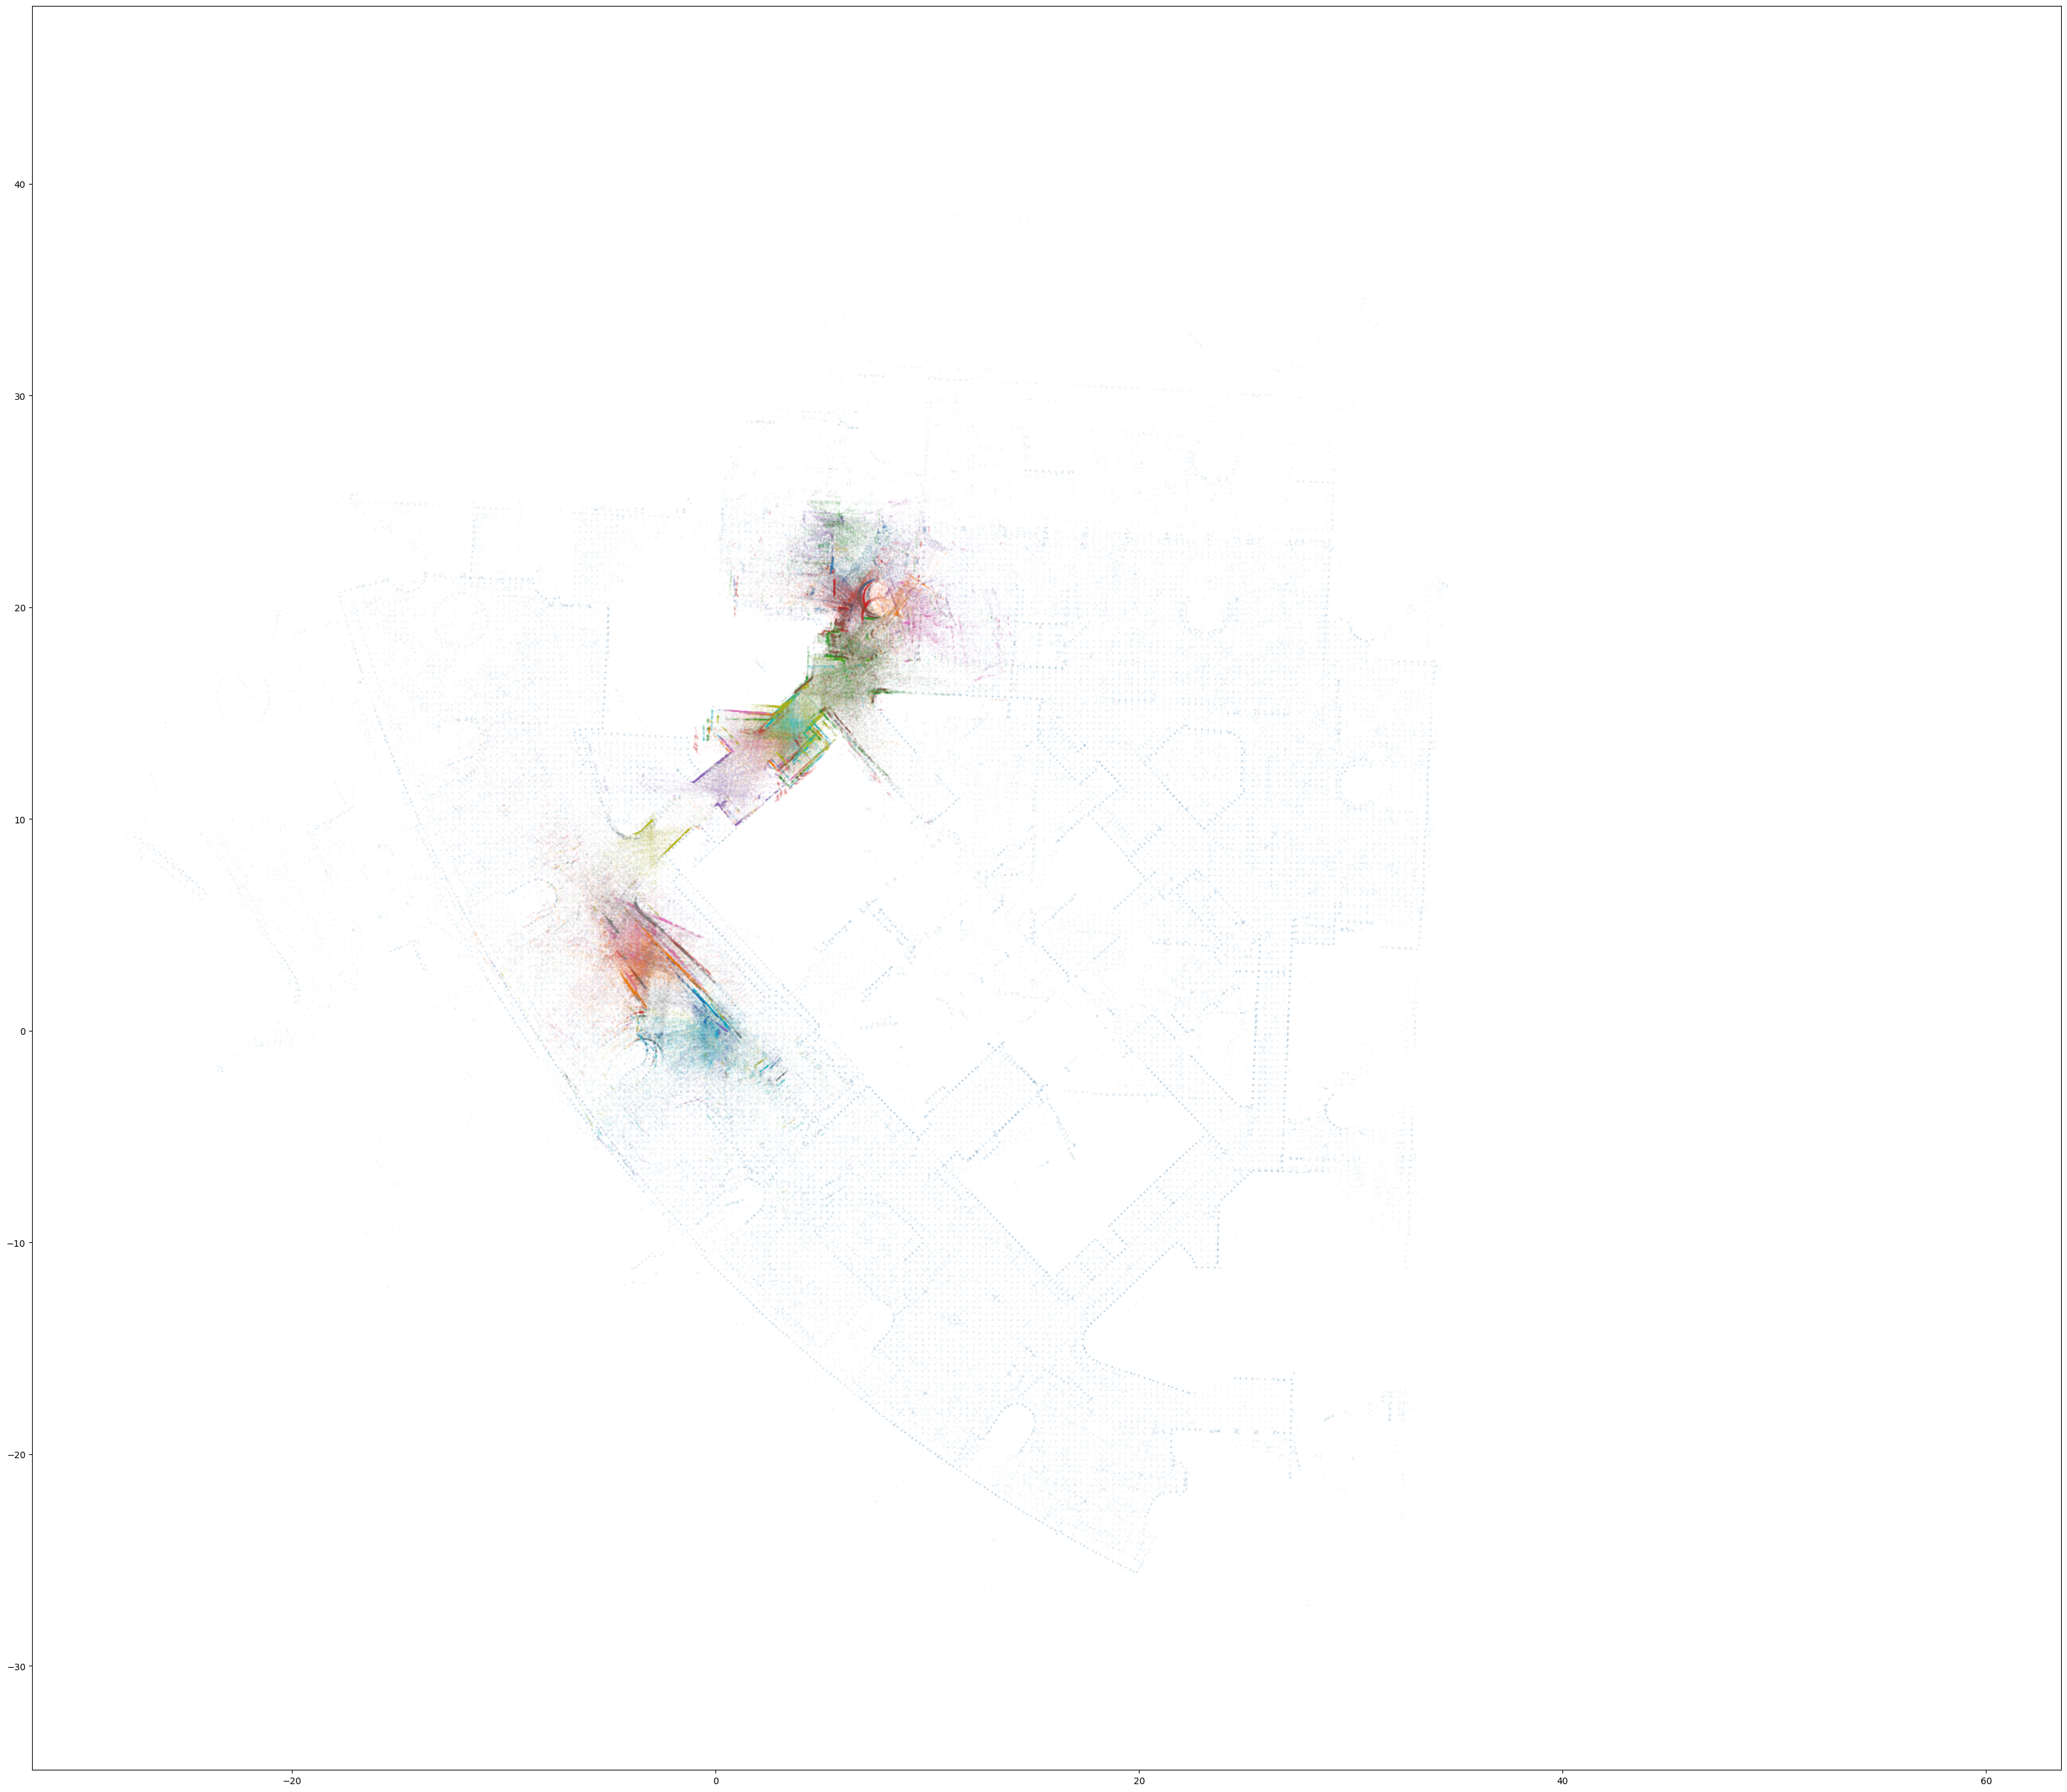

In [38]:
plt.figure(figsize=(40,35))
reference_metric_map_path = ROOT_DATA_DIR / "map1" / "metric_map" / "map_voxelized_0.3.pcd"
db_map_pcd = get_transformed_scan(reference_metric_map_path)
plt.scatter(db_map_pcd[:,0], db_map_pcd[:,1], s=0.001)


for i in range(50):
    QUERY_MAP = "map3/keyframe_map"      # Map used for testing queries
    query_map_dir = ROOT_DATA_DIR / QUERY_MAP
    QUERY_SCAN_ID = np.random.randint(0, 600)  # ID of the scan to use as query
    query_scan_path = query_map_dir / "scans" / f"{QUERY_SCAN_ID:06d}.pcd"
    
    localization_result = builder.infer_localization(
        pipeline=localization_pipeline,
        query_scan_path=query_scan_path,
        k=K_NEIGHBORS  # Use same number of candidates
    )
    #########
    ids = []
    gt_poses_on_db = []
    estimated_poses_on_db = []
    for c in localization_result.candidates:
        ids.append(c.idx)
        gt_poses_on_db.append(c.db_pose)
        estimated_poses_on_db.append(c.estimated_pose)
    
    gt_poses_on_db = Tf.from_quat(np.asarray(gt_poses_on_db)[:, 3:], np.asarray(gt_poses_on_db)[:, :3])
    estimated_poses_on_db = Tf.from_quat(np.asarray(estimated_poses_on_db)[:, 3:], np.asarray(estimated_poses_on_db)[:, :3])
    ##########

    best_transform, inlier_ids, outlier_ids = ransac_transformations(estimated_poses_on_db)
    if best_transform is None:
        continue
    pcd = get_transformed_scan(query_scan_path, best_transform, 0.3)
    plt.scatter(pcd[:,0], pcd[:,1], s=0.001)
    plt.axis('equal')
    #plt.show()
    print(query_scan_path, best_transform)#, best_transform.inv() * )


plt.savefig("kek.png")

In [35]:
plt.savefig('kek.jpg')

<Figure size 640x480 with 0 Axes>